# RotatE on FB15k-237 with custom two-stage negative sampling

This notebook reproduces the **custom RotatE** pipeline used in our D3 / DL-final
submissions. It trains RotatE on FB15k-237 with three negative-sampling strategies
(`random`, `hard`, `mixed`) drawn from a scored candidate pool, then evaluates each
checkpoint globally, per slice (relation frequency, head/tail degree), and qualitatively.

## Unified configuration shared with the baselines
* Loss: `NSSALoss(margin=9.0, adversarial_temperature=1.0)` (RotatE paper default)
* Sampler: Bernoulli with `filtered=True`, `num_negs_per_pos=8`
* Model: `embedding_dim=128`, Adam `lr=1e-3`, `batch_size=1024`
* Training: 50 epochs max, early stopping on filtered val MRR, `patience=10`
* Seed: 42

Only the **negative-selection strategy** changes between runs. The companion CLI is
`code/train_rotate_custom.py`; this notebook drives it with the exact same arguments
we used to produce our reported numbers.

## How to use
1. Set Colab runtime to **GPU (T4)** (Runtime ▸ Change runtime type).
2. Run all cells in order. Section A (setup) is a one-time install.
3. Section C **smoke-trains** one run (1 epoch, ~2 min) to validate the pipeline.
4. Section D shows the **full 50-epoch commands** for the five custom runs.
5. Section E loads any available checkpoints and produces the sliced / qualitative analyses.


## A. Setup (clone repo + install dependencies)

If the cell below fails because the repo is private, upload the contents of `code/` manually
to `/content/dl_kg_project/code/` and skip the `git clone` step.

In [1]:
import os, subprocess

REPO_URL  = "https://github.com/thaalia/dl_kg_project.git"  # private repo: clone may fail
REPO_PATH = "/content/dl_kg_project"
CODE_DIR  = os.path.join(REPO_PATH, "code")

if not os.path.isdir(CODE_DIR):
    if not os.path.isdir(REPO_PATH):
        result = subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, REPO_PATH],
            capture_output=True, text=True,
        )
        if result.returncode != 0:
            os.makedirs(CODE_DIR, exist_ok=True)
            print("git clone failed (private repo or no network access).")
            print("Manual upload required:")
            print(f"  1. In the Colab Files panel, navigate to {REPO_PATH}/code/")
            print("  2. Upload all .py files from your local code/ folder.")
            print("  3. Also upload requirements.txt at the repo root if not present.")
            print("\nClone stderr was:\n", result.stderr.strip())

os.chdir(REPO_PATH)
print("\nWorking directory:", os.getcwd())
print("Code files:", sorted(os.listdir("code")) if os.path.isdir("code") else "code/ not found yet")


Working directory: /content/dl_kg_project
Code files: ['__pycache__', 'evaluate_slices.py', 'negative_sampling.py', 'qualitative_examples.py', 'score_candidates.py', 'select_candidates.py', 'test_candidates.py', 'test_score_candidates.py', 'test_select_candidates.py', 'train_baseline_kge.py', 'train_baseline_kge_colab.ipynb', 'train_rotate_custom.py', 'train_rotate_custom_colab.ipynb']


In [2]:
%pip install -q -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 730.3/730.3 kB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.6 MB/s eta 0:00:00


In [3]:
import torch
print("PyTorch :", torch.__version__)
print("CUDA available :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU. Full training will be impractically slow on CPU.")

PyTorch : 2.11.0+cu128
CUDA available : True
GPU : Tesla T4


## B. Configuration

These parameters mirror the CLI flags of `code/train_rotate_custom.py` so that the notebook
produces the same artefacts as the script we report on.

In [4]:
MODEL                   = "RotatE"
DIM                     = 128
BATCH_SIZE              = 1024
LR                      = 1e-3
EPOCHS                  = 50          # 1 for smoke; 50 for the reported runs
PATIENCE                = 10
SEED                    = 42
POOL_SIZE               = 64
NUM_NEGS                = 8
MARGIN                  = 9.0
ADVERSARIAL_TEMPERATURE = 1.0
STRATEGY                = "mixed"     # one of: random | hard | mixed
HARD_FRACTION           = 0.5         # only used when STRATEGY == 'mixed'

# Artefacts will be written to: artifacts/custom/RotatE_<strategy>(_<hard%>_<rand%>)/
print("Strategy:", STRATEGY, "| hard_fraction:", HARD_FRACTION if STRATEGY == "mixed" else "n/a")

Strategy: mixed | hard_fraction: 0.5


## C. Smoke training (1 epoch, ~2 min) — validates the full pipeline

The smoke cell limits batches and val triples so it returns in a couple of minutes. Once it
completes you'll see `artifacts/custom/RotatE_mixed_50_50/summary.txt` updated with a tiny
`test_mrr` (the model has barely started learning); the goal of this step is purely to
confirm that candidate generation, scoring, selection and the loss back-prop chain run end-to-end
without errors.

In [5]:
!python code/train_rotate_custom.py \
    --strategy {STRATEGY} \
    --hard-fraction {HARD_FRACTION} \
    --num-negs {NUM_NEGS} \
    --pool-size {POOL_SIZE} \
    --epochs 1 \
    --batch-size 256 \
    --margin {MARGIN} \
    --adversarial-temperature {ADVERSARIAL_TEMPERATURE} \
    --seed {SEED} \
    --limit-batches 10 \
    --limit-val-eval 200

Loading FB15k-237 ...
You're trying to map triples with 30 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 28 from 20466 triples were filtered out
Training RotatE | strategy=mixed | d=128 | bs=256 | pool=64 | num_negs=8 | lr=0.001 | loss=NSSALoss(margin=9.0, adv_temp=1.0) | sampler=bernoulli_filtered | max_epochs=1 | patience=10 | device=cuda | hard_fraction=0.5
You're trying to map triples with 9 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 9 from 17535 triples were filtered out
Evaluating on cuda:0: 100% 200/200 [00:00<00:00, 779triple/s]  
Epoch 001 | loss=3.5279 | val MRR=0.0006
Evaluating on cuda:0: 100% 200/200 [00:00<00:00, 1.27ktriple/s]

=== Test metrics ===
val_mrr_best: 0.0006
test_mrr: 0.0004
test_hits_at_1: 0.0000
test_hits_at_3: 0.0000
test_hits_at_10: 0.0000

Artifacts saved to /content/dl_kg_project/artifacts/custom/RotatE_mixed_50

## D. Full reported runs (5 strategies × 50 epochs ≈ 4–5 h total on T4)

These are the exact commands that produced the numbers in our report. Each one writes its
own folder under `artifacts/custom/`. Do **not** mix git pulls between two runs that you
want to compare directly.

In [6]:
# Uncomment one (or more) of these to launch the full 50-epoch runs.
# Each command saves a summary, history JSON, learning-curve PNG, and trained_model.pkl.

# !python code/train_rotate_custom.py --strategy random                       --num-negs 8 --epochs 50 --patience 10
# !python code/train_rotate_custom.py --strategy hard                         --num-negs 8 --epochs 50 --patience 10
# !python code/train_rotate_custom.py --strategy mixed --hard-fraction 0.3    --num-negs 8 --epochs 50 --patience 10
# !python code/train_rotate_custom.py --strategy mixed --hard-fraction 0.5    --num-negs 8 --epochs 50 --patience 10
# !python code/train_rotate_custom.py --strategy mixed --hard-fraction 0.7    --num-negs 8 --epochs 50 --patience 10

## E. Sliced evaluation on every available checkpoint

`evaluate_slices.py` finds every `trained_model.pkl` under `artifacts/` and produces a
`slices.json` next to it. The buckets (low / mid / high) are computed once from the training
split only and cached in `artifacts/slice_buckets.json`, ensuring the same buckets are
reused across every run.

In [7]:
!python code/evaluate_slices.py --all

Found 5 checkpoint(s): ['artifacts/custom/RotatE_hard/trained_model.pkl', 'artifacts/custom/RotatE_mixed_30_70/trained_model.pkl', 'artifacts/custom/RotatE_mixed_50_50/trained_model.pkl', 'artifacts/custom/RotatE_mixed_70_30/trained_model.pkl', 'artifacts/custom/RotatE_random/trained_model.pkl']

=== Slicing artifacts/custom/RotatE_hard/trained_model.pkl ===
Loading FB15k-237 ...
You're trying to map triples with 30 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 28 from 20466 triples were filtered out
Loading model from /content/dl_kg_project/artifacts/custom/RotatE_hard/trained_model.pkl ...
You're trying to map triples with 9 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 9 from 17535 triples were filtered out
Evaluating global (20438 triples) ...
Evaluating axis: relation_frequency ...
Evaluating axis: head_degree ...
Evaluating axis: tail_degre

In [8]:
# Consolidate the per-run slices.json files into a single table.
import json
from pathlib import Path
import pandas as pd

rows = []
for slice_path in sorted(Path("artifacts").rglob("slices.json")):
    data = json.load(slice_path.open())
    g = data["global"]
    row = {
        "run": str(slice_path.parent.relative_to("artifacts")),
        "mrr": g["mrr"],
        "h@1": g["hits_at_1"],
        "h@3": g["hits_at_3"],
        "h@10": g["hits_at_10"],
        "mrr_head": g["mrr_head"],
        "mrr_tail": g["mrr_tail"],
    }
    for axis in ("relation_frequency", "head_degree", "tail_degree"):
        for bucket in ("low", "mid", "high"):
            row[f"{axis}.{bucket}"] = data[axis][bucket].get("mrr")
    rows.append(row)

df = pd.DataFrame(rows).set_index("run")
df.round(4)

,mrr,h@1,h@3,h@10,mrr_head,mrr_tail,relation_frequency.low,relation_frequency.mid,relation_frequency.high,head_degree.low,head_degree.mid,head_degree.high,tail_degree.low,tail_degree.mid,tail_degree.high
run,,,,,,,,,,,,,,,
custom/RotatE_hard,0.2982,0.2174,0.3268,0.4588,0.1939,0.4025,0.4176,0.3624,0.2844,0.2847,0.2682,0.3075,0.1867,0.1754,0.3298
custom/RotatE_mixed_30_70,0.2968,0.2148,0.3262,0.4592,0.1922,0.4013,0.4176,0.3618,0.2828,0.2834,0.2674,0.3059,0.1864,0.1742,0.3283
custom/RotatE_mixed_50_50,0.0008,0.0001,0.0002,0.0009,0.0006,0.0009,0.0010,0.0013,0.0007,0.0012,0.0008,0.0007,0.0007,0.0006,0.0008
custom/RotatE_mixed_70_30,0.2985,0.2165,0.3283,0.4607,0.1952,0.4017,0.4160,0.3622,0.2848,0.2830,0.2678,0.3083,0.1878,0.1746,0.3303
custom/RotatE_random,0.2702,0.1894,0.3004,0.4280,0.1692,0.3713,0.3821,0.3320,0.2571,0.2625,0.2505,0.2758,0.1570,0.1541,0.3013


## F. Qualitative comparison on a handful of test triples

`qualitative_examples.py` samples a few test triples (seed=42 by default) and, for each
model, prints the filtered rank of the gold entity plus the top-K predicted candidates on
both sides. The full report is saved to `artifacts/qualitative.md`.

In [9]:
!python code/qualitative_examples.py --num-triples 5

Device: cuda
Skipping missing checkpoints:
  /content/dl_kg_project/artifacts/baseline/pykeen_TransE/trained_model.pkl
  /content/dl_kg_project/artifacts/baseline/pykeen_RotatE/trained_model.pkl
Loading FB15k-237 ...
You're trying to map triples with 30 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 28 from 20466 triples were filtered out
You're trying to map triples with 9 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 9 from 17535 triples were filtered out
Loading artifacts/custom/RotatE_random/trained_model.pkl ...
Loading artifacts/custom/RotatE_hard/trained_model.pkl ...
Loading artifacts/custom/RotatE_mixed_50_50/trained_model.pkl ...

Qualitative report written to /content/dl_kg_project/artifacts/qualitative.md


In [10]:
# Preview the first ~120 lines of the qualitative report inline.
from IPython.display import Markdown
report = Path("artifacts/qualitative.md").read_text().splitlines()
Markdown("\n".join(report[:120]))

# Qualitative predictions on FB15k-237

_Sampled 5 test triples (seed=42). Top-10 candidates per side, filtered against the train+val+test triples._

## Triple 1: (/m/0btyf5z, /film/film/release_date_s./film/film_regional_release_date/film_release_region, /m/0345h)

### artifacts/custom/RotatE_random/trained_model.pkl
- **Tail prediction**: filtered rank of gold tail `/m/0345h` = **9**
  - `/m/0jgd` (score=-6.271)
  - `/m/035qy` (score=-6.282)
  - `/m/05b4w` (score=-6.330)
  - `/m/03rj0` (score=-6.335)
  - `/m/06mkj` (score=-6.344)
  - `/m/03_3d` (score=-6.404)
  - `/m/0chghy` (score=-6.410)
  - `/m/0154j` (score=-6.414)
  - `/m/0345h` (score=-6.415) ←gold
  - `/m/05v8c` (score=-6.419)
- **Head prediction**: filtered rank of gold head `/m/0btyf5z` = **19**
  - `/m/09gmmt6` (score=-5.844)
  - `/m/0gh65c5` (score=-5.950)
  - `/m/049w1q` (score=-5.952)
  - `/m/03yvf2` (score=-6.000)
  - `/m/0m491` (score=-6.117)
  - `/m/01xlqd` (score=-6.183)
  - `/m/0gvvm6l` (score=-6.195)
  - `/m/01shy7` (score=-6.252)
  - `/m/08j7lh` (score=-6.286)
  - `/m/02pxst` (score=-6.304)

### artifacts/custom/RotatE_hard/trained_model.pkl
- **Tail prediction**: filtered rank of gold tail `/m/0345h` = **1**
  - `/m/0345h` (score=-7.358) ←gold
  - `/m/06mkj` (score=-7.408)
  - `/m/03_3d` (score=-7.445)
  - `/m/0jgd` (score=-7.478)
  - `/m/05qhw` (score=-7.497)
  - `/m/015fr` (score=-7.509)
  - `/m/0chghy` (score=-7.519)
  - `/m/035qy` (score=-7.520)
  - `/m/05b4w` (score=-7.574)
  - `/m/0154j` (score=-7.603)
- **Head prediction**: filtered rank of gold head `/m/0btyf5z` = **19**
  - `/m/03yvf2` (score=-6.776)
  - `/m/0m491` (score=-6.850)
  - `/m/0gvvm6l` (score=-6.860)
  - `/m/049w1q` (score=-6.866)
  - `/m/0gh65c5` (score=-6.948)
  - `/m/0g5879y` (score=-6.966)
  - `/m/01shy7` (score=-7.092)
  - `/m/09gmmt6` (score=-7.098)
  - `/m/0gvvf4j` (score=-7.122)
  - `/m/04yg13l` (score=-7.179)

### artifacts/custom/RotatE_mixed_50_50/trained_model.pkl
- **Tail prediction**: filtered rank of gold tail `/m/0345h` = **192**
  - `/m/01kstn9` (score=-1.745)
  - `/m/0478__m` (score=-1.772)
  - `/m/02rqxc` (score=-1.774)
  - `/m/0qmfk` (score=-1.791)
  - `/m/0n59t` (score=-1.795)
  - `/m/039c26` (score=-1.796)
  - `/m/0pswc` (score=-1.797)
  - `/m/04mp75` (score=-1.798)
  - `/m/01fx4k` (score=-1.800)
  - `/m/05j0wc` (score=-1.801)
- **Head prediction**: filtered rank of gold head `/m/0btyf5z` = **1015**
  - `/m/06jzh` (score=-1.691)
  - `/m/02k84w` (score=-1.696)
  - `/m/01bcwk` (score=-1.721)
  - `/m/01hvzr` (score=-1.721)
  - `/m/02lyr4` (score=-1.723)
  - `/m/0155w` (score=-1.730)
  - `/m/01gf5` (score=-1.733)
  - `/m/0xrzh` (score=-1.734)
  - `/m/04fhn_` (score=-1.735)
  - `/m/0g72r` (score=-1.735)

## Triple 2: (/m/03ryks, /music/artist/track_contributions./music/track_contribution/role, /m/013y1f)

### artifacts/custom/RotatE_random/trained_model.pkl
- **Tail prediction**: filtered rank of gold tail `/m/013y1f` = **3**
  - `/m/026t6` (score=-5.499)
  - `/m/042v_gx` (score=-5.632)
  - `/m/013y1f` (score=-5.710) ←gold
  - `/m/0342h` (score=-5.743)
  - `/m/05148p4` (score=-5.841)
  - `/m/01vj9c` (score=-5.859)
  - `/m/03qjg` (score=-5.898)
  - `/m/03gvt` (score=-6.025)
  - `/m/07brj` (score=-6.138)
  - `/m/07y_7` (score=-6.164)
- **Head prediction**: filtered rank of gold head `/m/03ryks` = **2**
  - `/m/01vsyg9` (score=-5.669)
  - `/m/03ryks` (score=-5.710) ←gold
  - `/m/01p95y0` (score=-5.748)
  - `/m/01wsl7c` (score=-5.836)
  - `/m/0565cz` (score=-5.850)
  - `/m/023l9y` (score=-5.944)
  - `/m/01lvcs1` (score=-6.023)
  - `/m/018gkb` (score=-6.035)
  - `/m/0140t7` (score=-6.035)
  - `/m/01mwsnc` (score=-6.049)

### artifacts/custom/RotatE_hard/trained_model.pkl
- **Tail prediction**: filtered rank of gold tail `/m/013y1f` = **4**
  - `/m/0342h` (score=-6.951)
  - `/m/042v_gx` (score=-6.984)
  - `/m/026t6` (score=-7.086)
  - `/m/013y1f` (score=-7.109) ←gold
  - `/m/05148p4` (score=-7.265)
  - `/m/03qjg` (score=-7.368)
  - `/m/03gvt` (score=-7.489)
  - `/m/01vj9c` (score=-7.500)
  - `/m/07brj` (score=-7.671)
  - `/m/01s0ps` (score=-7.726)
- **Head prediction**: filtered rank of gold head `/m/03ryks` = **2**
  - `/m/01vsyg9` (score=-7.073)
  - `/m/03ryks` (score=-7.109) ←gold
  - `/m/01p95y0` (score=-7.211)

## G. Headline visualisations

Two figures we use in the report: (1) global MRR per strategy, and (2) MRR vs `tail in-degree`
bucket, which is the slice that benefits most from hard-negative sampling.

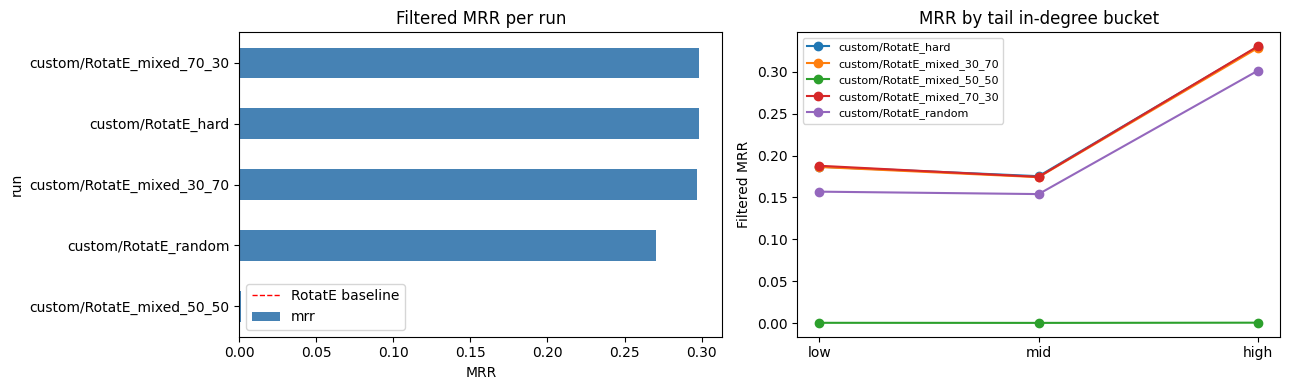

In [11]:
import matplotlib.pyplot as plt

if df.empty:
    print("No checkpoints found; run sections C or D first.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    df["mrr"].sort_values().plot.barh(ax=axes[0], color="steelblue")
    axes[0].set_title("Filtered MRR per run")
    axes[0].set_xlabel("MRR")
    axes[0].axvline(df.loc[df.index.str.contains("pykeen_RotatE")]["mrr"].mean(),
                    color="red", linestyle="--", linewidth=1, label="RotatE baseline")
    axes[0].legend()

    cols = ["tail_degree.low", "tail_degree.mid", "tail_degree.high"]
    df[cols].T.plot(ax=axes[1], marker="o")
    axes[1].set_title("MRR by tail in-degree bucket")
    axes[1].set_xticks(range(3))
    axes[1].set_xticklabels(["low", "mid", "high"])
    axes[1].set_ylabel("Filtered MRR")
    axes[1].legend(loc="upper left", fontsize=8)
    fig.tight_layout()
    fig.savefig("artifacts/d3_headline_figures.png", dpi=150)
    plt.show()

## H. Notes for graders

* The negative-sampling logic lives in three small modules:
  * `code/negative_sampling.py` — Bernoulli corruption + train-triple filter.
  * `code/score_candidates.py` — batched scoring of candidate triples.
  * `code/select_candidates.py` — `random` / `hard` / `mixed` selection from the scored pool.
* The training driver `code/train_rotate_custom.py` calls `model.post_parameter_update()`
  after every optimiser step to keep RotatE's relation embeddings on the complex unit circle,
  matching what PyKEEN's `pipeline()` does internally. This step was essential for the
  NSSALoss to converge.
* `code/evaluate_slices.py` and `code/qualitative_examples.py` are pure post-hoc tools that
  consume a `trained_model.pkl` and do not retrain anything.
